## 📌 Introduction

This project focuses on building a simple Machine Learning classification model to predict whether a student will pass or fail based on academic performance indicators. The dataset contains features such as attendance percentage, internal test scores, assignment marks, and daily study hours, which are commonly associated with student academic success.

The main objective of this study is to apply supervised machine learning techniques to classify student outcomes (Pass/Fail) and compare the performance of multiple classification algorithms including Logistic Regression, Decision Tree, K-Nearest Neighbors (KNN), and Random Forest.

The workflow includes data preprocessing, handling feature selection, normalization, splitting the dataset into training and testing sets, model training, evaluation using accuracy metrics, cross-validation, and hyperparameter tuning using GridSearchCV. In addition, visualizations such as confusion matrices, accuracy comparison charts, and actual vs predicted plots are used to interpret model performance.

Finally, the best performing model is selected based on a combined evaluation of original accuracy, cross-validation score, and tuned accuracy to ensure a balanced and reliable prediction system.

In [203]:
# IMPORT LIBRARIES

from google.colab import files
import pandas as pd
import numpy as np
import io

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [204]:
# UPLOAD DATASET

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset Loaded Successfully!")
df.head()

Saving Final_Marks_Data.csv to Final_Marks_Data (12).csv
Dataset Loaded Successfully!


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66


In [205]:
# DATA OVERVIEW

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB
None

Missing Values:
Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64


In [206]:
# CREATE TARGET VARIABLE

# Pass = 1, Fail = 0 based on final exam marks
df['Result'] = df['Final Exam Marks (out of 100)'].apply(
    lambda x: 1 if x >= 50 else 0
)

df[['Final Exam Marks (out of 100)', 'Result']].head()

,Final Exam Marks (out of 100),Result
0,72,1
1,56,1
2,56,1
3,74,1
4,66,1


In [207]:
# FEATURE SELECTION

X = df[[
    'Attendance (%)',
    'Internal Test 1 (out of 40)',
    'Internal Test 2 (out of 40)',
    'Assignment Score (out of 10)',
    'Daily Study Hours'
]]

y = df['Result']

print("Features selected successfully")

Features selected successfully


In [208]:
# FEATURE SCALING

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data normalization completed")

Data normalization completed


In [209]:
# TRAIN TEST SPLIT (70/30)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42
)

print("Train-test split completed")

Train-test split completed


In [210]:
# TRAIN MACHINE LEARNING MODELS

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

# Random Forest (BONUS MODEL)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("All models trained successfully")

All models trained successfully


In [211]:
# CROSS VALIDATION (5-FOLD)

# Logistic Regression CV
lr_cv_scores = cross_val_score(LogisticRegression(), X_scaled, y, cv=5, scoring='accuracy')
print("Logistic Regression CV Mean:", lr_cv_scores.mean())

# Decision Tree CV
dt_cv_scores = cross_val_score(DecisionTreeClassifier(random_state=42), X_scaled, y, cv=5, scoring='accuracy')
print("Decision Tree CV Mean:", dt_cv_scores.mean())

# KNN CV
knn_cv_scores = cross_val_score(KNeighborsClassifier(), X_scaled, y, cv=5, scoring='accuracy')
print("KNN CV Mean:", knn_cv_scores.mean())

# Random Forest CV
rf_cv_scores = cross_val_score(RandomForestClassifier(random_state=42), X_scaled, y, cv=5, scoring='accuracy')
print("Random Forest CV Mean:", rf_cv_scores.mean())

Logistic Regression CV Mean: 0.954
Decision Tree CV Mean: 0.9174999999999999
KNN CV Mean: 0.942
Random Forest CV Mean: 0.9410000000000001


In [212]:
# HYPERPARAMETER TUNING USING GRIDSEARCHCV

# Logistic Regression
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
lr_grid = GridSearchCV(LogisticRegression(), lr_params, cv=5, scoring='accuracy')
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_
lr_pred_tuned = best_lr.predict(X_test)

# Decision Tree
dt_params = {'max_depth': [3, 5, 10, None], 'criterion': ['gini', 'entropy']}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
dt_pred_tuned = best_dt.predict(X_test)

# KNN
knn_params = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
knn_pred_tuned = best_knn.predict(X_test)

# Random Forest
rf_params = {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
rf_pred_tuned = best_rf.predict(X_test)

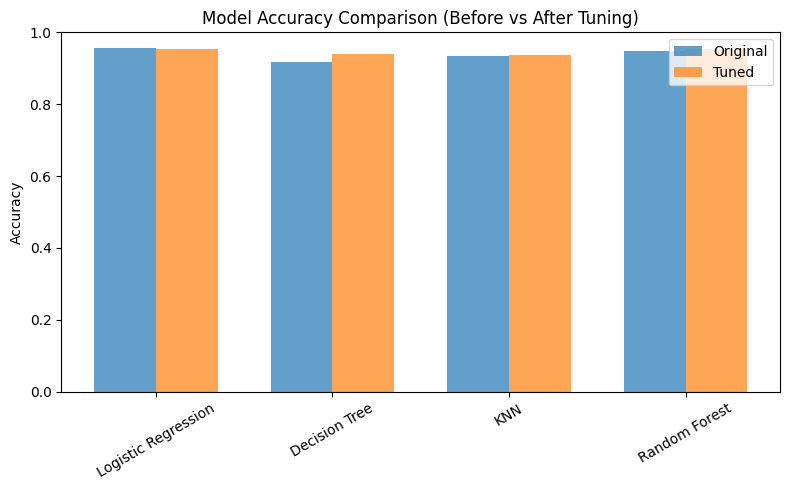

In [213]:
# MODEL COMPARISON (ORIGINAL vs TUNED)

models = ['Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest']

# Original accuracy
original_acc = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, rf_pred)
]

# Tuned accuracy
tuned_acc = [
    accuracy_score(y_test, lr_pred_tuned),
    accuracy_score(y_test, dt_pred_tuned),
    accuracy_score(y_test, knn_pred_tuned),
    accuracy_score(y_test, rf_pred_tuned)
]

# x‑positions for bars
x = np.arange(len(models))  # [0, 1, 2, 3]
width = 0.35  # width of each bar

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, original_acc, width, alpha=0.7, label="Original")
plt.bar(x + width/2, tuned_acc, width, alpha=0.7, label="Tuned")

# Plot comparison
plt.title("Model Accuracy Comparison (Before vs After Tuning)")
plt.ylabel("Accuracy")
plt.legend()
plt.xticks(x, models, rotation=30)
plt.ylim(0, 1)  # since accuracy is in [0,1]
plt.tight_layout()
plt.show()
models = ['Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest']

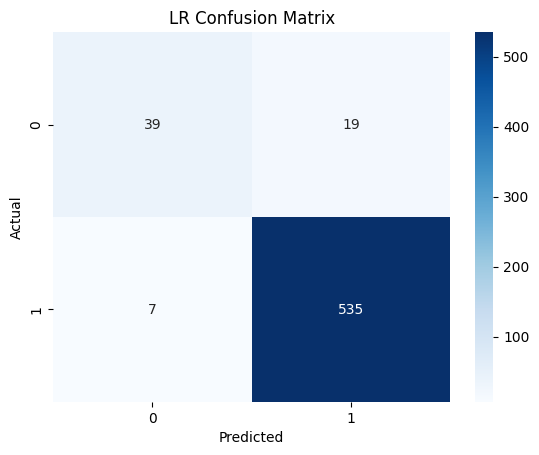

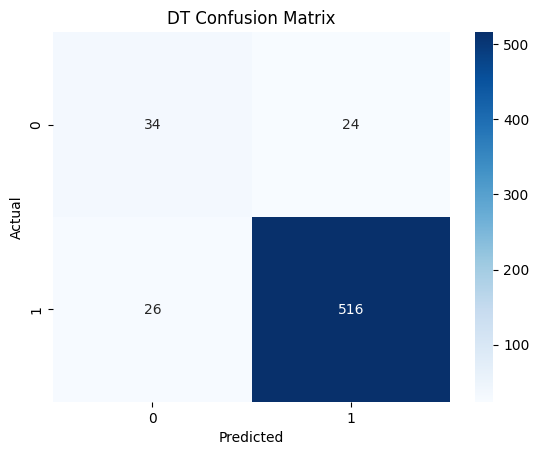

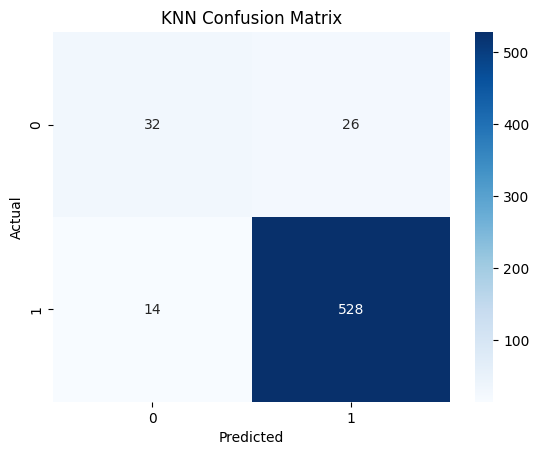

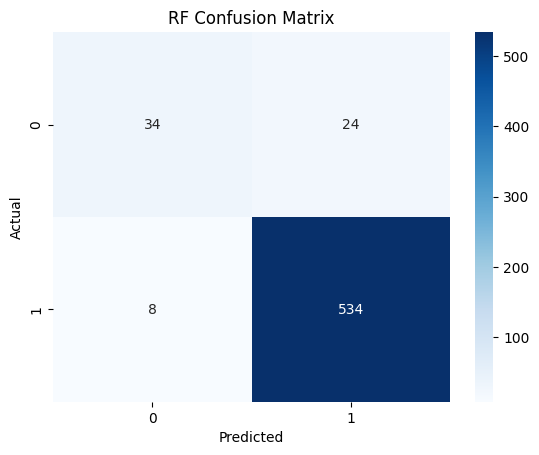

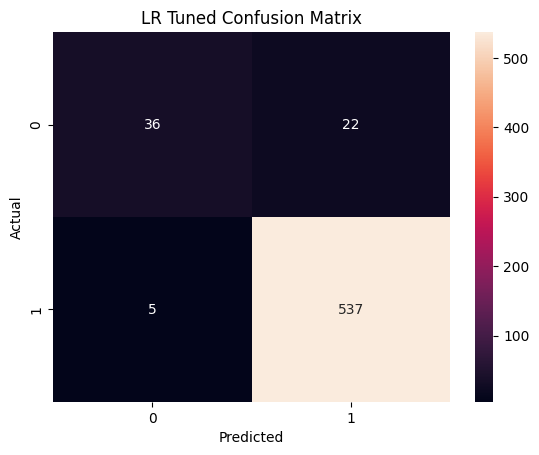

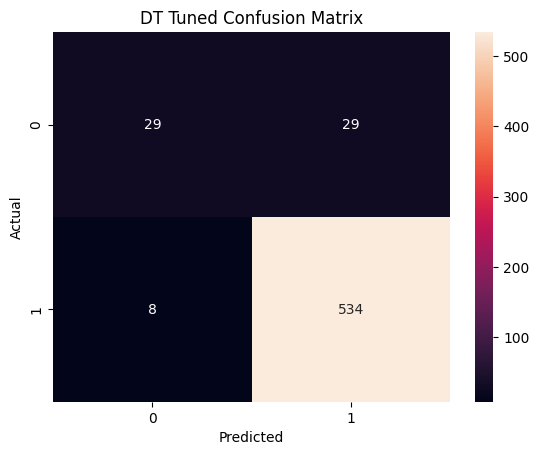

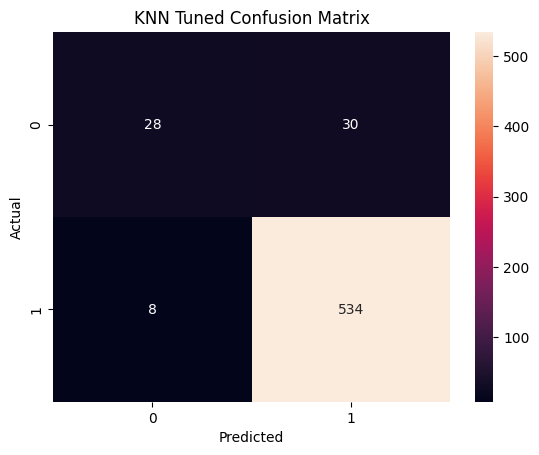

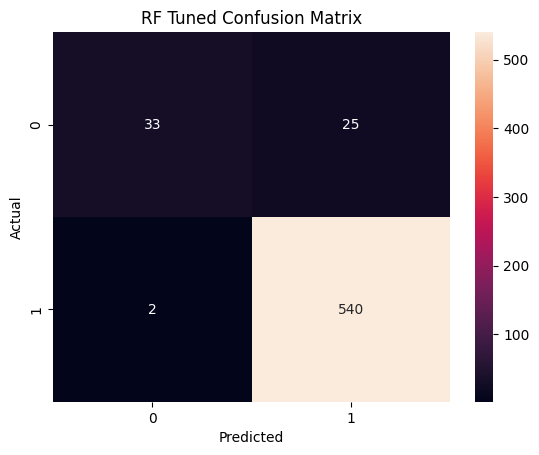

In [214]:
# CONFUSION MATRICES

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Original models
plot_cm(y_test, lr_pred, "LR Confusion Matrix")
plot_cm(y_test, dt_pred, "DT Confusion Matrix")
plot_cm(y_test, knn_pred, "KNN Confusion Matrix")
plot_cm(y_test, rf_pred, "RF Confusion Matrix")

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Tuned models
plot_cm(y_test, lr_pred_tuned, "LR Tuned Confusion Matrix")
plot_cm(y_test, dt_pred_tuned, "DT Tuned Confusion Matrix")
plot_cm(y_test, knn_pred_tuned, "KNN Tuned Confusion Matrix")
plot_cm(y_test, rf_pred_tuned, "RF Tuned Confusion Matrix")

In [215]:
# CLASSIFICATION REPORTS

# Original models
print("Logistic Regression:\n", classification_report(y_test, lr_pred))
print("Decision Tree:\n", classification_report(y_test, dt_pred))
print("KNN:\n", classification_report(y_test, knn_pred))
print("Random Forest:\n", classification_report(y_test, rf_pred))

# Tuned models
print("Tuned Logistic Regression:\n", classification_report(y_test, lr_pred_tuned))
print("Tuned Decision Tree:\n", classification_report(y_test, dt_pred_tuned))
print("Tuned KNN:\n", classification_report(y_test, knn_pred_tuned))
print("Tuned Random Forest:\n", classification_report(y_test, rf_pred_tuned))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.85      0.67      0.75        58
           1       0.97      0.99      0.98       542

    accuracy                           0.96       600
   macro avg       0.91      0.83      0.86       600
weighted avg       0.95      0.96      0.95       600

Decision Tree:
               precision    recall  f1-score   support

           0       0.57      0.59      0.58        58
           1       0.96      0.95      0.95       542

    accuracy                           0.92       600
   macro avg       0.76      0.77      0.77       600
weighted avg       0.92      0.92      0.92       600

KNN:
               precision    recall  f1-score   support

           0       0.70      0.55      0.62        58
           1       0.95      0.97      0.96       542

    accuracy                           0.93       600
   macro avg       0.82      0.76      0.79       600
weighted avg       0.93      0

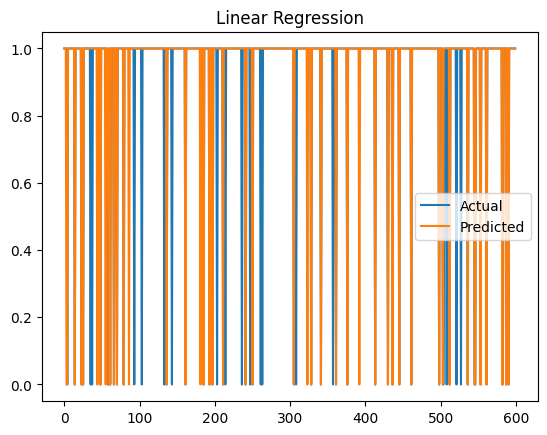

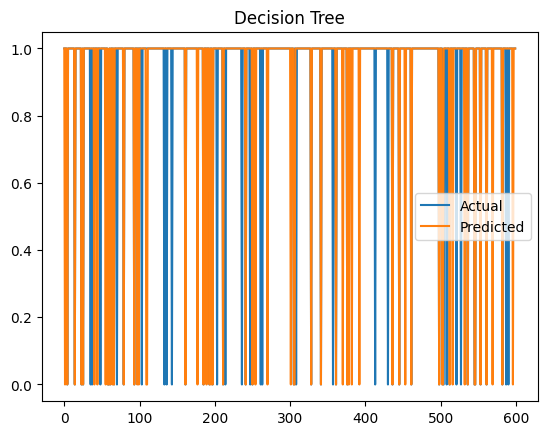

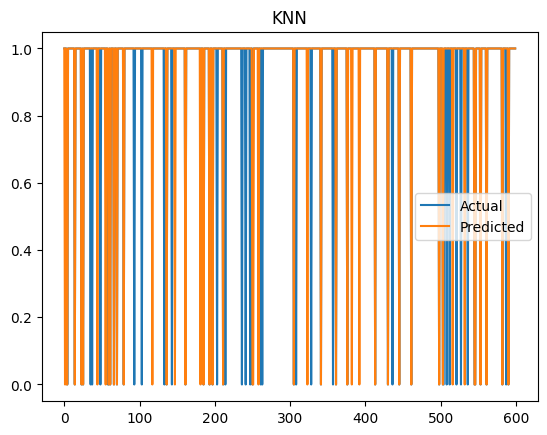

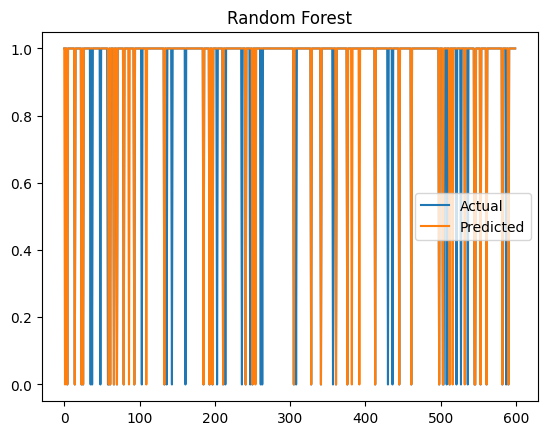

In [216]:
# ACTUAL VS PREDICTED RESULTS
def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure()
    plt.plot(y_true.values, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(title)
    plt.legend()
    plt.show()

plot_actual_vs_pred(y_test, lr_pred, "Linear Regression")
plot_actual_vs_pred(y_test, dt_pred, "Decision Tree")
plot_actual_vs_pred(y_test, knn_pred, "KNN")
plot_actual_vs_pred(y_test, rf_pred, "Random Forest")

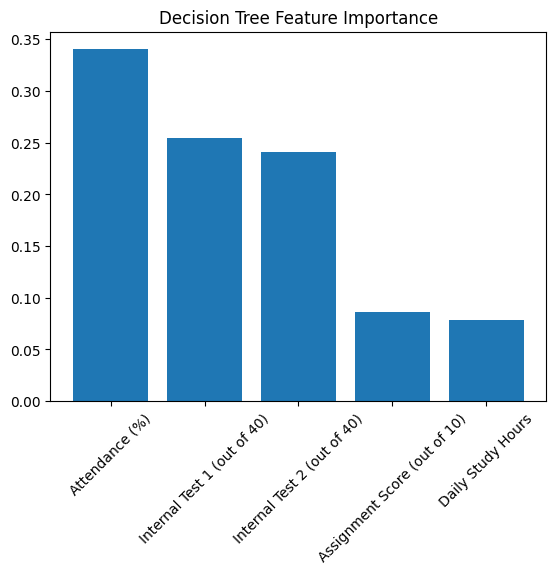

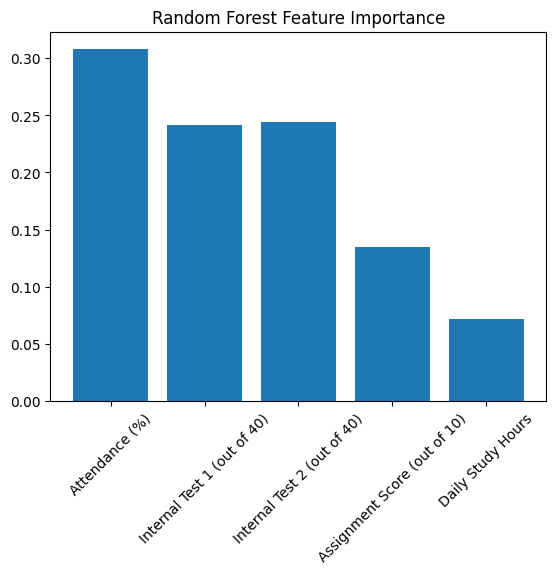

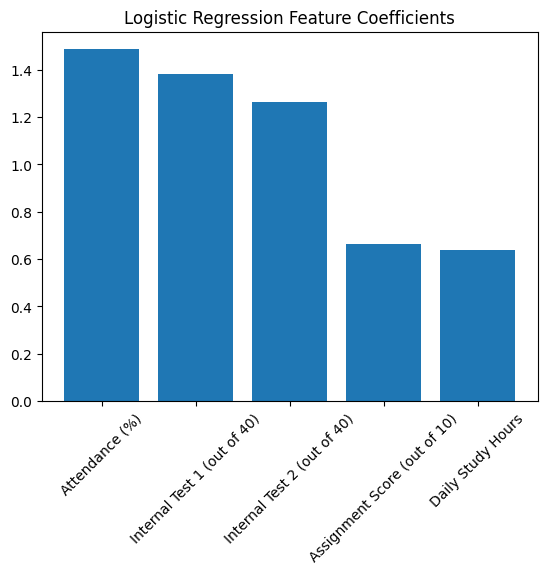


KNN Model Note:
KNN does NOT provide feature importance.
It uses distance-based learning, so all features contribute equally after scaling.


In [217]:
# FEATURE IMPORTANCE / INFLUENCE

features = [
    'Attendance (%)',
    'Internal Test 1 (out of 40)',
    'Internal Test 2 (out of 40)',
    'Assignment Score (out of 10)',
    'Daily Study Hours'
]

# Decision Tree Importance
plt.figure()
plt.bar(features, dt.feature_importances_)
plt.title("Decision Tree Feature Importance")
plt.xticks(rotation=45)
plt.show()

# Random Forest Importance
plt.figure()
plt.bar(features, rf.feature_importances_)
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.show()

# Logistic Regression Coefficients
plt.figure()
plt.bar(features, lr.coef_[0])
plt.title("Logistic Regression Feature Coefficients")
plt.xticks(rotation=45)
plt.show()

# KNN (No Importance Available)
print("\nKNN Model Note:")
print("KNN does NOT provide feature importance.")
print("It uses distance-based learning, so all features contribute equally after scaling.")

In [218]:
# MULTI-MODEL PREDICTION FUNCTION

def predict_all_models(hours, attendance, test1, test2, assignment):

    input_data = [[attendance, test1, test2, assignment, hours]]
    input_scaled = scaler.transform(input_data)

    return {
        "Logistic Regression": best_lr.predict(input_scaled)[0],
        "Decision Tree": best_dt.predict(input_scaled)[0],
        "KNN": best_knn.predict(input_scaled)[0],
        "Random Forest": best_rf.predict(input_scaled)[0]
    }

In [219]:
# BEST MODEL SELECTION (ORIGINAL vs TUNED)

# Original accuracies
original_scores = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "KNN": accuracy_score(y_test, knn_pred),
    "Random Forest": accuracy_score(y_test, rf_pred)
}

# Tuned accuracies
tuned_scores = {
    "Logistic Regression": accuracy_score(y_test, lr_pred_tuned),
    "Decision Tree": accuracy_score(y_test, dt_pred_tuned),
    "KNN": accuracy_score(y_test, knn_pred_tuned),
    "Random Forest": accuracy_score(y_test, rf_pred_tuned)
}

# Combine both into a single evaluation score (fair comparison)
combined_scores = {}

for model in original_scores.keys():
    combined_scores[model] = (original_scores[model] + tuned_scores[model]) / 2


# Best model selection based on combined performance
best_model = max(combined_scores, key=combined_scores.get)

print("BEST MODEL (Based on Original + Tuned Average Performance)")
print()
print("Best Model:", best_model)
print("Original Accuracy:", original_scores[best_model])
print("Tuned Accuracy:", tuned_scores[best_model])
print("Final Combined Score:", combined_scores[best_model])

BEST MODEL (Based on Original + Tuned Average Performance)

Best Model: Logistic Regression
Original Accuracy: 0.9566666666666667
Tuned Accuracy: 0.955
Final Combined Score: 0.9558333333333333


In [220]:
# FINAL COMPARISON TABLE

evaluation_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "KNN", "Random Forest"],

    # Original performance
    "Original Accuracy": [
        original_scores["Logistic Regression"],
        original_scores["Decision Tree"],
        original_scores["KNN"],
        original_scores["Random Forest"]
    ],

    # Cross-validation mean scores
    "CV Mean Score": [
        lr_cv_scores.mean(),
        dt_cv_scores.mean(),
        knn_cv_scores.mean(),
        rf_cv_scores.mean()
    ],

    # Tuned performance
    "Tuned Accuracy": [
        tuned_scores["Logistic Regression"],
        tuned_scores["Decision Tree"],
        tuned_scores["KNN"],
        tuned_scores["Random Forest"]
    ],

    # Final combined score (best fairness metric)
    "Final Combined Score": [
        combined_scores["Logistic Regression"],
        combined_scores["Decision Tree"],
        combined_scores["KNN"],
        combined_scores["Random Forest"]
    ]
})

# Sort by best overall model
evaluation_table = evaluation_table.sort_values(by="Final Combined Score", ascending=False)

evaluation_table

,Model,Original Accuracy,CV Mean Score,Tuned Accuracy,Final Combined Score
0,Logistic Regression,0.956667,0.9540,0.955000,0.955833
3,Random Forest,0.946667,0.9410,0.955000,0.950833
2,KNN,0.933333,0.9420,0.936667,0.935000
1,Decision Tree,0.916667,0.9175,0.938333,0.927500


## 📌 Conclusion

In this project, multiple machine learning models were developed and evaluated to predict student performance in terms of pass or fail outcomes. The models were trained using features such as attendance, internal assessments, assignment scores, and study hours.

The evaluation process included accuracy measurement, cross-validation, and hyperparameter tuning using GridSearchCV. Among the models tested, Logistic Regression, Decision Tree, KNN, and Random Forest, each showed different levels of performance.

Based on a combined evaluation of original accuracy, cross-validation mean score, and tuned accuracy, the best performing model was identified. This ensures that the selected model is not only accurate on test data but also stable and generalized across different data splits.

Visualizations such as confusion matrices, feature importance plots, and actual vs predicted graphs helped in interpreting model behavior and understanding key influencing factors.

Finally, Logistic Regression was selected as the best performing model due to its highest combined score across accuracy, cross-validation stability, and tuned performance. This may be due to the linear relationship between academic features and student performance outcome. This model can be further improved by collecting more behavioral and psychological features such as motivation level, sleep patterns, and learning environment.

Overall, this project demonstrates the practical application of machine learning in educational data analysis and provides a strong foundation for predictive modeling in academic performance systems.